## Install kaggle library

### Subtask:
Install the Kaggle library in your Colab environment.


**Reasoning**:
Install the kaggle library using pip.



In [1]:
!pip install kaggle

In [5]:
import os

# Check if kaggle.json exists
print("kaggle.json exists:", os.path.exists("kaggle.json"))

kaggle.json exists: True


In [6]:
import os

# Create both folders just in case
os.makedirs("/root/.kaggle", exist_ok=True)
os.makedirs("/root/.config/kaggle", exist_ok=True)

# Move the kaggle.json to both locations
!mv kaggle.json /root/.kaggle/
!cp /root/.kaggle/kaggle.json /root/.config/kaggle/

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json


In [7]:
!kaggle datasets download mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.19GB/s]


In [8]:
import zipfile

with zipfile.ZipFile("creditcardfraud.zip", "r") as zip_ref:
    zip_ref.extractall("creditcard_fraud_data")

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB

In [10]:
df = pd.read_csv("/content/creditcard_fraud_data/creditcard.csv")

## Data Cleaning and previewing

In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df.shape

(284807, 31)

In [13]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [14]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Exploratory Data Analysis

### The DataSet is pretty unbalaced to built model

In [16]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


/tmp/ipython-input-17-2751551921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)


Text(0.5, 1.0, 'Class Distributions \n (Red: No Fraud || Blue: Fraud)')

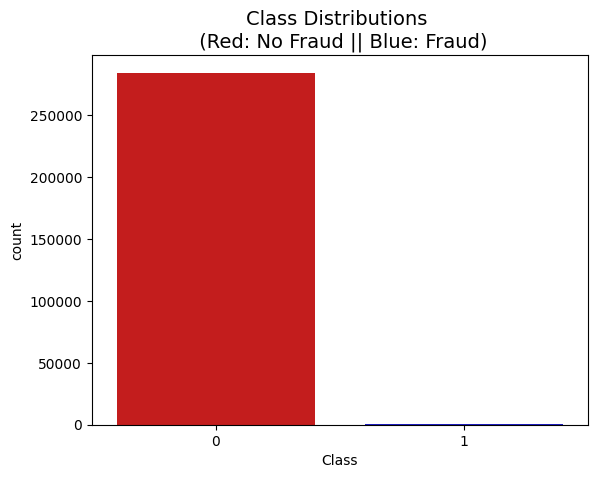

In [17]:
colors = ["#DF0101","#0101DF"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (Red: No Fraud || Blue: Fraud)', fontsize=14)

### Standard Scaling:
It will help to ensures equal contribution of each column by Standardization of the column magnitude.

In [19]:
# Scale 'Amount' and 'Time'
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original 'Amount' and 'Time'
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Rearranging columns (optional)
scaled_features = ['scaled_amount', 'scaled_time']
remaining_features = [col for col in df.columns if col not in scaled_features + ['Class']]
df = df[scaled_features + remaining_features + ['Class']]


In [ ]:
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


### Random Under-Sampling:
In this phase of the project we will implement "Random Under Sampling" which basically consists of removing data in order to have a more balanced dataset and thus avoiding our models to overfitting.

In [20]:
shuffled_df = df.sample(frac=1, random_state=42)
fraud_df = shuffled_df[shuffled_df['Class'] == 1]
non_fraud_df = shuffled_df[shuffled_df['Class'] == 0][:len(fraud_df)]

balanced_df = pd.concat([fraud_df, non_fraud_df])
balanced_df = balanced_df.sample(frac=1, random_state=42)

In [21]:
balanced_df['Class'].value_counts()

,count
Class,
0,492
1,492


In [22]:
balanced_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
146884,-0.293579,0.038170,2.054361,-0.122642,-1.245717,0.189567,0.132497,-0.620765,0.059581,-0.148058,...,-0.209856,-0.271204,-0.687048,0.271569,-0.497120,-0.270115,0.208619,-0.076075,-0.075428,0
95597,18.615944,-0.226824,-2.923827,1.524837,-3.018758,3.289291,-5.755542,2.218276,-0.509995,-3.569444,...,-0.447039,-0.511657,-0.122724,-4.288639,0.563797,-0.949451,-0.204532,1.510206,-0.324706,1
96768,1.872424,-0.220456,0.955253,-0.833374,0.847147,0.725970,-1.322868,-0.238842,-0.565347,0.022443,...,-0.294785,-0.110554,-0.129397,-0.040892,0.364872,0.204756,-0.304578,0.055908,0.062489,0
75511,2.080905,-0.335930,-1.229669,1.956099,-0.851198,2.796987,-1.913977,-0.044934,-1.340739,-0.555548,...,0.270459,1.208054,0.277612,0.019266,0.508529,-0.201183,-0.249600,0.562239,0.075309,1
255556,-0.296653,0.852830,-0.242245,4.147186,-5.672349,6.493741,1.591168,-1.602523,-0.950463,0.722903,...,0.562030,0.249023,-0.480286,-0.286080,-1.153575,-0.035571,0.559628,0.409446,0.221048,1


In [23]:
balanced_df.shape

(984, 31)

### Let's drew some Heat Map to get correlation between columns

<Axes: >

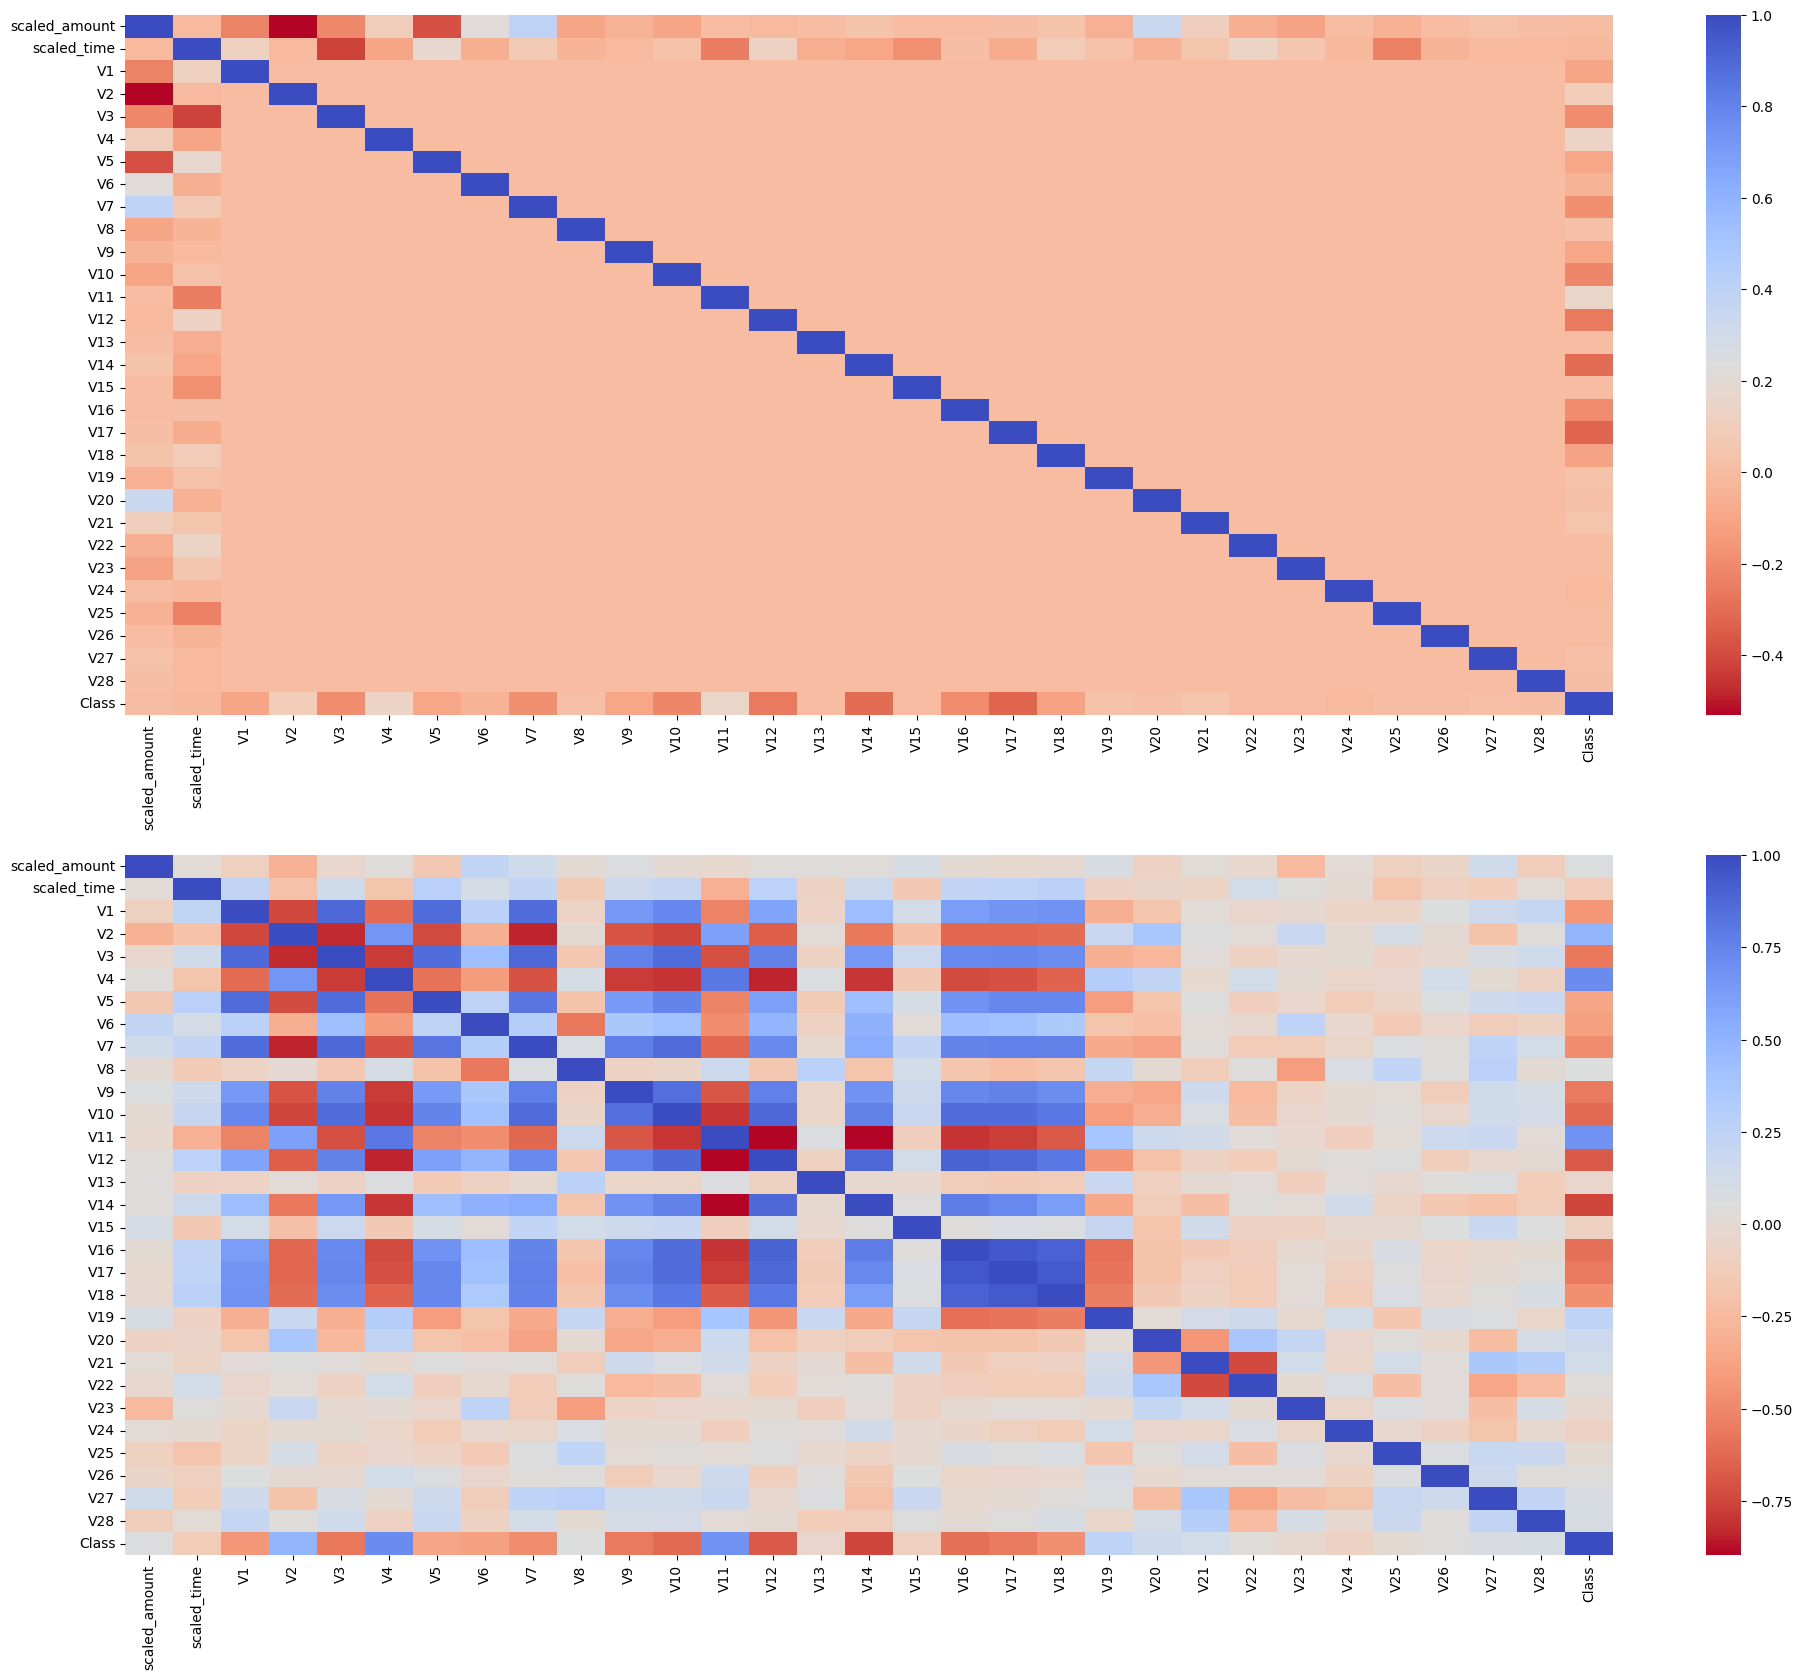

In [24]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Correlation Heatmap of Previous dataframe
prev_corr = df.corr()
prev_corr.style.background_gradient(cmap='coolwarm')
sns.heatmap(prev_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)

# Correlation Heatmap of New dataframe
new_corr = balanced_df.corr()
new_corr.style.background_gradient(cmap='coolwarm')
sns.heatmap(new_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)

## Anomaly Detection:
We will identify relevent input columns that significantly impacts Class column.

In [25]:
X = balanced_df.drop('Class', axis=1)
Y = balanced_df['Class']

### Dimensionality reduction:
we are reduction 30 columns to 2 columns using PCA(Principal Component Analysis).
We can't visualize high-dimensional data, but we can visualize 2D data that's why PCA is needed.

In [26]:
X_pca = PCA(n_components=2).fit_transform(X.values)


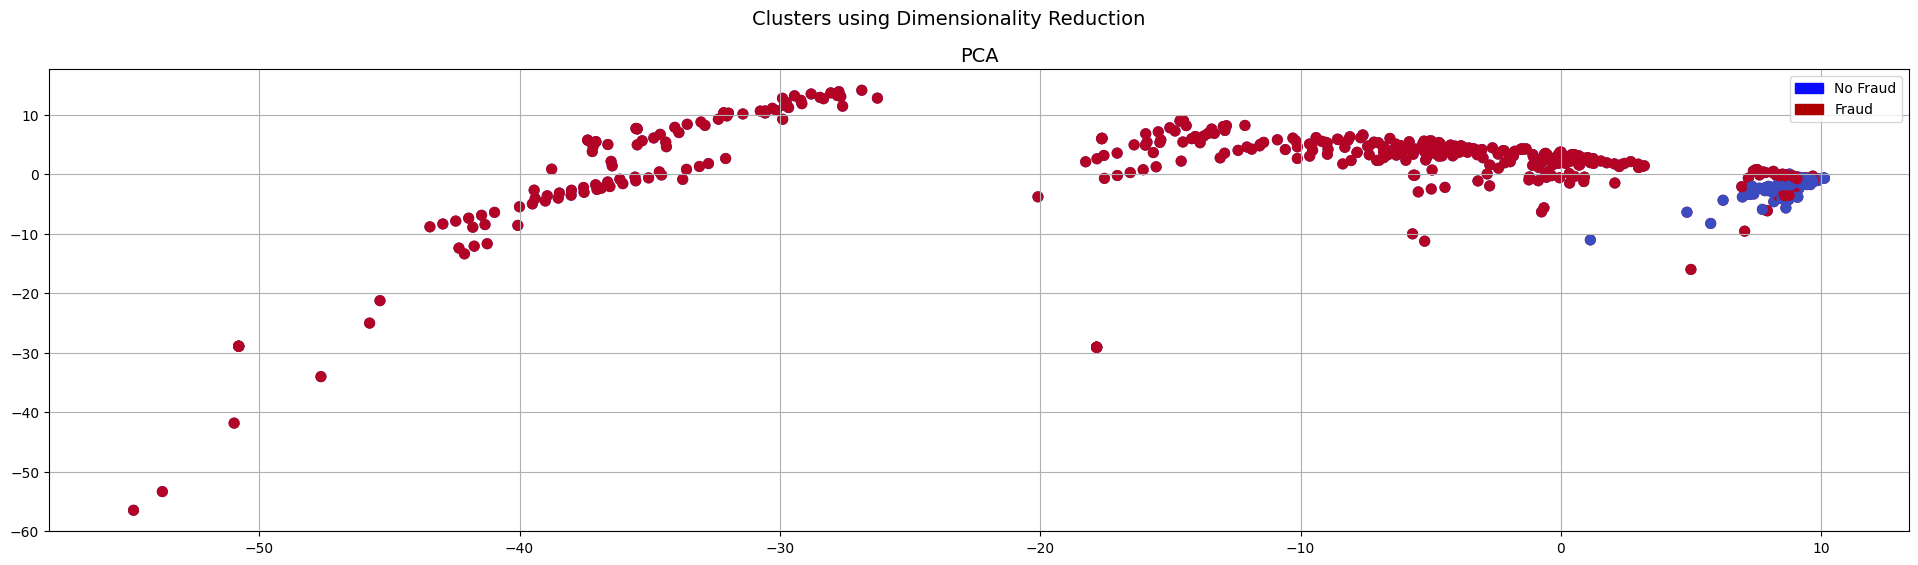

In [27]:
f, (ax) = plt.subplots(1, 1, figsize=(24,6))
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)

blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


ax.scatter(X_pca[:,0], X_pca[:,1], c=(Y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax.scatter(X_pca[:,0], X_pca[:,1], c=(Y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax.set_title('PCA', fontsize=14)

ax.grid(True)

ax.legend(handles=[blue_patch, red_patch])

## Classifiers Testing:
we will be identifying best classifiers by comparing those for better accuracy.

#### Test Train Split


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, random_state=42)

In [29]:
classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "Support Vector Classifier": SVC(probability=True),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "GaussianNB": GaussianNB(),
    "XGBoost": xgb.XGBClassifier()
}

In [30]:
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    training_score = cross_val_score(model, X_train, y_train, cv=5)
    print("Classifiers: ", name, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score\n\n")

Classifiers:  LogisiticRegression Has a training score of 95.0 % accuracy score


Classifiers:  KNearest Has a training score of 93.0 % accuracy score


Classifiers:  RandomForest Has a training score of 94.0 % accuracy score


Classifiers:  Support Vector Classifier Has a training score of 94.0 % accuracy score


Classifiers:  DecisionTreeClassifier Has a training score of 89.0 % accuracy score


Classifiers:  GaussianNB Has a training score of 93.0 % accuracy score


Classifiers:  XGBoost Has a training score of 94.0 % accuracy score




## Improvising Model accuracy

#### Receiver Operating Characteristic(ROC) score

In [32]:
for name, model in classifiers.items():
    print(f"🔍 {name}")
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        print(f"Classifier {name} does not have predict_proba or decision_function.")
        continue

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_proba), "\n")

🔍 LogisiticRegression
[[ 81   6]
 [ 10 100]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91        87
           1       0.94      0.91      0.93       110

    accuracy                           0.92       197
   macro avg       0.92      0.92      0.92       197
weighted avg       0.92      0.92      0.92       197

ROC AUC Score: 0.974921630094044 

🔍 KNearest
[[83  4]
 [12 98]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91        87
           1       0.96      0.89      0.92       110

    accuracy                           0.92       197
   macro avg       0.92      0.92      0.92       197
weighted avg       0.92      0.92      0.92       197

ROC AUC Score: 0.9703239289446186 

🔍 RandomForest
[[83  4]
 [13 97]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.91        87
           1       0.96      0.88      0.92       110

  

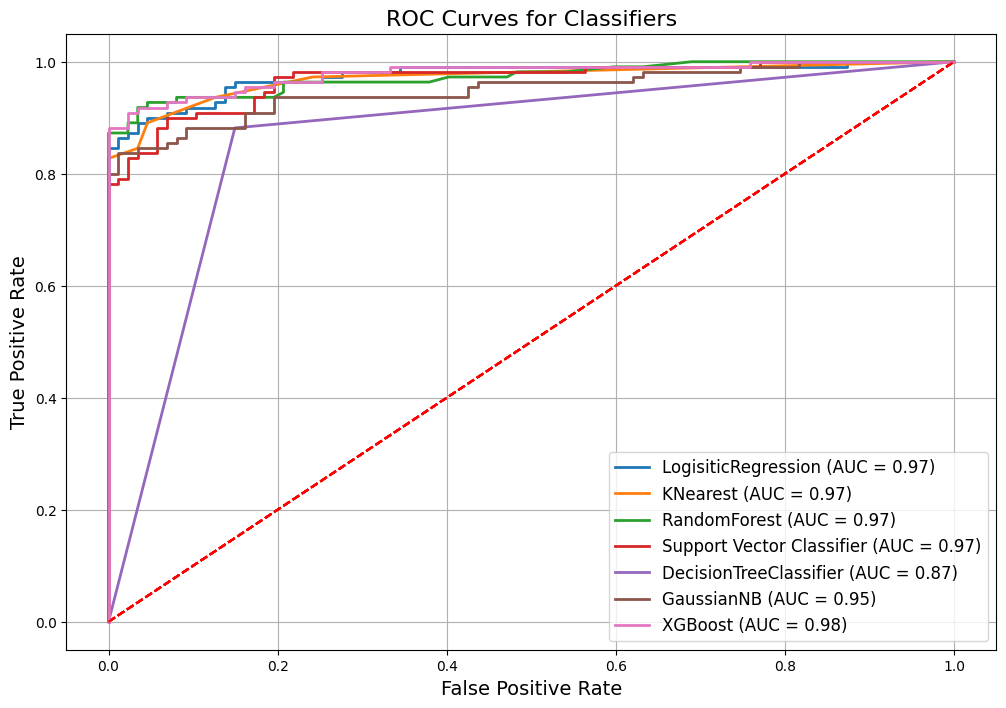

In [33]:
def logistic_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'r--')

plt.figure(figsize=(12, 8))
plt.title('ROC Curves for Classifiers', fontsize=16)

for name, model in classifiers.items():
    # Use scaled data for models sensitive to feature scale
    model.fit(X_train, y_train)

    # Handle models without predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        print(f"Classifier {name} does not have predict_proba or decision_function, skipping ROC curve.")
        continue


    fpr, tpr, _ = roc_curve(y_test, y_prob)
    logistic_roc_curve(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

### GridSearchCV to find optimal model parameters.

In [35]:
# Logistic Regression
# 'lbfgs' solver only supports 'l2' penalty
log_reg_params = {"penalty": ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(solver='lbfgs', max_iter=1000), log_reg_params, cv=5)
grid_log_reg.fit(X_train, y_train)
log_reg = grid_log_reg.best_estimator_


# KNears Neighbour
knears_params = {"n_neighbors": list(range(2,5,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params, cv=5)
grid_knears.fit(X_train, y_train)
knears_neighbors = grid_knears.best_estimator_


# RandomForest classifier
random_forest_params = {'n_estimators': [10, 20, 50, 100], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}

grid_random_forest = GridSearchCV(RandomForestClassifier(), random_forest_params, cv=5)
grid_random_forest.fit(X_train, y_train)
random_forest_clf = grid_random_forest.best_estimator_

# Support Vector Classifier
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}

grid_svc = GridSearchCV(SVC(probability=True), svc_params, cv=5)
grid_svc.fit(X_train, y_train)
svc = grid_svc.best_estimator_


# DecisionTree Classifier
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)),
              "min_samples_leaf": list(range(5,7,1))}

grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params, cv=5)
grid_tree.fit(X_train, y_train)
tree_clf = grid_tree.best_estimator_

# XGBoost Classifier
xgb_params = {'objective': ['binary:logistic'], 'n_estimators': [10, 50, 100], 'learning_rate': [0.01, 0.1, 0.5]}

grid_xgb = GridSearchCV(xgb.XGBClassifier(), xgb_params, cv=5)
grid_xgb.fit(X_train, y_train)
xgb_clf = grid_xgb.best_estimator_

In [37]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%\n\n')

knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%\n\n')

random_forest_score = cross_val_score(random_forest_clf, X_train, y_train, cv=5)
print('Random Forest Cross Validation Score', round(random_forest_score.mean() * 100, 2).astype(str) + '%\n\n')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%\n\n')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%\n\n')

xgb_score = cross_val_score(xgb_clf, X_train, y_train, cv=5)
print('XGBoost Classifier Cross Validation Score', round(xgb_score.mean() * 100, 2).astype(str) + '%\n\n')

Logistic Regression Cross Validation Score:  94.92%


Knears Neighbors Cross Validation Score 93.52%


Random Forest Cross Validation Score 94.54%


Support Vector Classifier Cross Validation Score 94.41%


DecisionTree Classifier Cross Validation Score 92.5%


XGBoost Classifier Cross Validation Score 94.79%




#### F1-Score,ROC AUC and recall values after hypertuning

In [38]:
tunedClassifiers = {
    "LogisiticRegression": log_reg,
    "KNearest": knears_neighbors,
    "RandomForest": random_forest_clf,
    "Support Vector Classifier": svc,
    "DecisionTreeClassifier": tree_clf,
    "XGBoost": xgb_clf
}

In [39]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score

In [44]:
f1_scores = {}
roc_auc_scores = {}
recall_scores = {}

for name, model in tunedClassifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    f1_scores[name] = f1_score(y_test, y_pred)
    roc_auc_scores[name] = roc_auc_score(y_test, y_proba)
    recall_scores[name] = recall_score(y_test, y_pred)
    print(f"🔍 {name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"F1 Score: {f1_scores[name]}")
    print(f"ROC AUC Score: {roc_auc_scores[name]}")
    print(f"Recall Score: {recall_scores[name]}\n\n")

🔍 LogisiticRegression
[[82  5]
 [12 98]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.91        87
           1       0.95      0.89      0.92       110

    accuracy                           0.91       197
   macro avg       0.91      0.92      0.91       197
weighted avg       0.92      0.91      0.91       197

F1 Score: 0.92018779342723
ROC AUC Score: 0.974712643678161
Recall Score: 0.8909090909090909


🔍 KNearest
[[ 83   4]
 [ 10 100]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        87
           1       0.96      0.91      0.93       110

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197

F1 Score: 0.9345794392523364
ROC AUC Score: 0.9667189132706374
Recall Score: 0.9090909090909091


🔍 RandomForest
[[83  4]
 [14 96]]
              precision    recall  f1-score 

### SMOTE:
SMOTE stands for Synthetic Minority Over-sampling Technique. Unlike Random UnderSampling, SMOTE creates new synthetic points in order to have an equal balance of the classes. This is another alternative for solving the "class imbalance problems".

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_orig, y_train_orig)

smoteClassifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier()
}


In [53]:
for name, model in smoteClassifiers.items():
    print("Model: ",name)
    model.fit(X_train_smote, y_train_smote)
    training_score = cross_val_score(model, X_train_smote, y_train_smote, cv=3)
    print("Training score of", round(training_score.mean(), 2) * 100, "% accuracy score\n\n")

Model:  LogisiticRegression
Training score of 95.0 % accuracy score


Model:  KNearest
Training score of 100.0 % accuracy score


Model:  RandomForest
Training score of 100.0 % accuracy score


Model:  XGBoost
Training score of 100.0 % accuracy score




In [56]:
f1_scores_smote = {}
roc_auc_scores_smote = {}
recall_scores_smote = {}

for name, model in smoteClassifiers.items():
    y_pred = model.predict(X_test_orig)
    y_proba = model.predict_proba(X_test_orig)[:, 1]
    f1_scores_smote[name] = f1_score(y_test_orig, y_pred)
    roc_auc_scores_smote[name] = roc_auc_score(y_test_orig, y_proba)
    recall_scores_smote[name] = recall_score(y_test_orig, y_pred)
    print(f"🔍 {name}")
    print(confusion_matrix(y_test_orig, y_pred))
    print(classification_report(y_test_orig, y_pred))
    print(f"F1 Score: {f1_scores_smote[name]}")
    print(f"ROC AUC Score: {roc_auc_scores_smote[name]}")
    print(f"Recall Score: {recall_scores_smote[name]}\n\n")

🔍 LogisiticRegression
[[55463  1401]
 [    7    91]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.93      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

F1 Score: 0.11446540880503145
ROC AUC Score: 0.978079815212523
Recall Score: 0.9285714285714286


🔍 KNearest
[[56769    95]
 [   12    86]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.48      0.88      0.62        98

    accuracy                           1.00     56962
   macro avg       0.74      0.94      0.81     56962
weighted avg       1.00      1.00      1.00     56962

F1 Score: 0.6164874551971327
ROC AUC Score: 0.9383346086042745
Recall Score: 0.8775510204081632


🔍 RandomForest
[[56856     8]
 [   16    82]]
         